# Qwen Image Edit Text Rendering Failure Study

This notebook is a research lab for understanding when Qwen Image Edit renders text correctly and when it fails.

Scope for the first pass:

- Fix seed, scheduler, CFG, steps, resolution, and prompt style.
- Compare the same simple text task across English, Arabic, and Chinese.
- Separate likely bottlenecks:
  - tokenizer / language conditioning
  - VAE glyph preservation
  - DiT/flow denoising and layout formation
  - editing pathway vs text-to-image pathway
  - prompt/data prior
- Mark conclusions as **Observed**, **Measured**, **Likely**, or **Unknown**.

I will avoid pretending to know causes that this notebook does not directly prove.

## Reading List

Primary Qwen references:

- [Qwen-Image Technical Report](https://arxiv.org/abs/2508.02324)
- [Qwen-Image GitHub repository](https://github.com/QwenLM/Qwen-Image)
- [Qwen/Qwen-Image-Edit model card](https://huggingface.co/Qwen/Qwen-Image-Edit)
- [Qwen2.5-VL blog](https://qwen.ai/blog?id=qwen2.5-vl)

Background needed to understand the system:

- [Latent Diffusion Models](https://arxiv.org/abs/2112.10752) — why image models often denoise in VAE latent space.
- [Scalable Diffusion Models with Transformers / DiT](https://arxiv.org/abs/2212.09748) — why transformer backbones replaced UNets in many high-end generators.
- [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747) — the objective family behind many flow-based image samplers.
- [Classifier-Free Diffusion Guidance](https://arxiv.org/abs/2207.12598) — why CFG/true-CFG changes prompt adherence vs quality.
- [AnyText: Multilingual Visual Text Generation and Editing](https://arxiv.org/abs/2311.03054) — useful comparison point for text-specific image generation.
- [GlyphDraw](https://arxiv.org/abs/2303.17870) — older but useful for thinking about glyph-aware supervision.

Keep in mind: some Qwen-Image internals are visible from local configs and Diffusers code; training-data details and exact learned representations are not directly observable here.

In [1]:
from __future__ import annotations

import base64
import io
import json
import math
import os
import time
import urllib.request
from pathlib import Path
from typing import Any

import arabic_reshaper
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from bidi.algorithm import get_display
from diffusers import AutoencoderKLQwenImage
from IPython.display import Image as IPyImage, Markdown, display
from PIL import Image, ImageDraw, ImageFont, ImageOps
from skimage.metrics import structural_similarity as ssim
from transformers import AutoTokenizer

ROOT = Path("/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-production")
MODEL_DIR = ROOT / "official-models/Qwen-Image-Edit-2511"
OUT = ROOT / "outputs/qwen_text_failure_study"
OUT.mkdir(parents=True, exist_ok=True)
SYNTH_DIR = OUT / "synthetic_controls"
VAE_DIR = OUT / "vae_recon"
API_DIR = OUT / "api_matrix"
for d in [SYNTH_DIR, VAE_DIR, API_DIR]:
    d.mkdir(parents=True, exist_ok=True)

API = "http://127.0.0.1:8001/v1/edit"
FIXED_SEED = 20260616
WIDTH = 768
HEIGHT = 768
STEPS = 40
TRUE_CFG_SCALE = 4.0
SCHEDULER_EXPECTED = "beta"

FONT_LATIN = Path("/opt/conda/fonts/DejaVuSans.ttf")
FONT_AR_REG = ROOT / "assets/fonts/NotoSansArabic-Regular.ttf"
FONT_AR_BOLD = ROOT / "assets/fonts/NotoSansArabic-Bold.ttf"
FONT_CJK = ROOT / "assets/fonts/NotoSansCJKsc-Regular.otf"

if os.environ.get("CUDA_VISIBLE_DEVICES"):
    VAE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
else:
    VAE_DEVICE = "cuda:1" if torch.cuda.device_count() > 1 else ("cuda" if torch.cuda.is_available() else "cpu")

print("root:", ROOT)
print("output:", OUT)
print("vae_device:", VAE_DEVICE)
print("torch:", torch.__version__)

2026-06-17 09:53:22.429976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781690002.442535 3748233 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781690002.446493 3748233 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-17 09:53:22.460045: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


root: /mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-production
output: /mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-production/outputs/qwen_text_failure_study
vae_device: cuda
torch: 2.6.0


## 1. Local Architecture Facts

These facts come from the local model files, not from guessing.

In [2]:
def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text())

configs = {
    "model_index": read_json(MODEL_DIR / "model_index.json"),
    "text_encoder": read_json(MODEL_DIR / "text_encoder/config.json"),
    "transformer": read_json(MODEL_DIR / "transformer/config.json"),
    "vae": read_json(MODEL_DIR / "vae/config.json"),
    "scheduler": read_json(MODEL_DIR / "scheduler/scheduler_config.json"),
    "processor": read_json(MODEL_DIR / "processor/preprocessor_config.json"),
}

rows = [
    ("pipeline", configs["model_index"].get("_class_name"), "Overall Diffusers pipeline"),
    ("text_encoder", configs["text_encoder"].get("architectures"), configs["text_encoder"].get("model_type")),
    ("transformer", configs["transformer"].get("_class_name"), f'{configs["transformer"].get("num_layers")} layers, {configs["transformer"].get("num_attention_heads")} heads'),
    ("vae", configs["vae"].get("_class_name"), "Encodes/decodes RGB image <-> latent"),
    ("scheduler", configs["scheduler"].get("_class_name"), f'use_dynamic_shifting={configs["scheduler"].get("use_dynamic_shifting")}'),
    ("processor", configs["processor"].get("processor_class"), configs["processor"].get("image_processor_type")),
]
arch_df = pd.DataFrame(rows, columns=["component", "class_or_arch", "note"])
display(arch_df)

important = {
    "transformer_num_layers": configs["transformer"].get("num_layers"),
    "transformer_attention_heads": configs["transformer"].get("num_attention_heads"),
    "transformer_attention_head_dim": configs["transformer"].get("attention_head_dim"),
    "transformer_in_channels": configs["transformer"].get("in_channels"),
    "transformer_out_channels": configs["transformer"].get("out_channels"),
    "transformer_patch_size": configs["transformer"].get("patch_size"),
    "joint_attention_dim": configs["transformer"].get("joint_attention_dim"),
    "text_encoder_hidden_size": configs["text_encoder"].get("hidden_size"),
    "text_encoder_layers": configs["text_encoder"].get("num_hidden_layers"),
    "scheduler_base_shift": configs["scheduler"].get("base_shift"),
    "scheduler_max_shift": configs["scheduler"].get("max_shift"),
    "scheduler_time_shift_type": configs["scheduler"].get("time_shift_type"),
}
display(pd.DataFrame([important]).T.rename(columns={0: "value"}))

,component,class_or_arch,note
0,pipeline,QwenImageEditPlusPipeline,Overall Diffusers pipeline
1,text_encoder,[Qwen2_5_VLForConditionalGeneration],qwen2_5_vl
2,transformer,QwenImageTransformer2DModel,"60 layers, 24 heads"
3,vae,AutoencoderKLQwenImage,Encodes/decodes RGB image <-> latent
4,scheduler,FlowMatchEulerDiscreteScheduler,use_dynamic_shifting=True
5,processor,Qwen2VLProcessor,Qwen2VLImageProcessorFast


,value
transformer_num_layers,60
transformer_attention_heads,24
transformer_attention_head_dim,128
transformer_in_channels,64
transformer_out_channels,16
transformer_patch_size,2
joint_attention_dim,3584
text_encoder_hidden_size,3584
text_encoder_layers,28
scheduler_base_shift,0.5


In [3]:
def get_json(url: str, timeout: int = 10):
    with urllib.request.urlopen(url, timeout=timeout) as response:
        return json.load(response)

health = get_json("http://127.0.0.1:8001/health")
queue = get_json("http://127.0.0.1:8001/v1/queue")
display(pd.DataFrame([health]).T.rename(columns={0: "health"}))
print("queue:", queue)

assert health["ok"] is True
assert str(MODEL_DIR) == health["model_dir"]
assert health["default_steps"] == STEPS
assert abs(float(health["default_true_cfg_scale"]) - TRUE_CFG_SCALE) < 1e-6

,health
ok,True
model_dir,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
device,cuda
dtype,bf16
default_steps,40
default_true_cfg_scale,4.0
scheduler,beta
stochastic_sampling,False
queue_max_size,64
queued,0


queue: {'max_size': 64, 'queued': 0, 'running': 0, 'succeeded_retained': 6, 'failed_retained': 0, 'completed_retention_seconds': 900.0, 'batching_supported': False}


## 2. Architecture Drawing

Qwen Image Edit uses a dual input path for editing:

- The input image goes through **Qwen2.5-VL** for semantic/visual-language conditioning.
- The input image also goes through the **VAE encoder** for reconstructive appearance information.
- The prompt/text conditioning and image latent stream condition a large image transformer.
- A flow-matching scheduler iteratively denoises latents.
- The VAE decoder converts final latents back to RGB.

What we can test:

- tokenizer behavior
- VAE reconstruction behavior
- sampler/prompt/seed output behavior

What we cannot directly inspect without deeper instrumentation/training data:

- which individual transformer heads encode glyph identity
- exact training distribution for Arabic vs Chinese vs English
- whether a given failure is caused by one specific layer

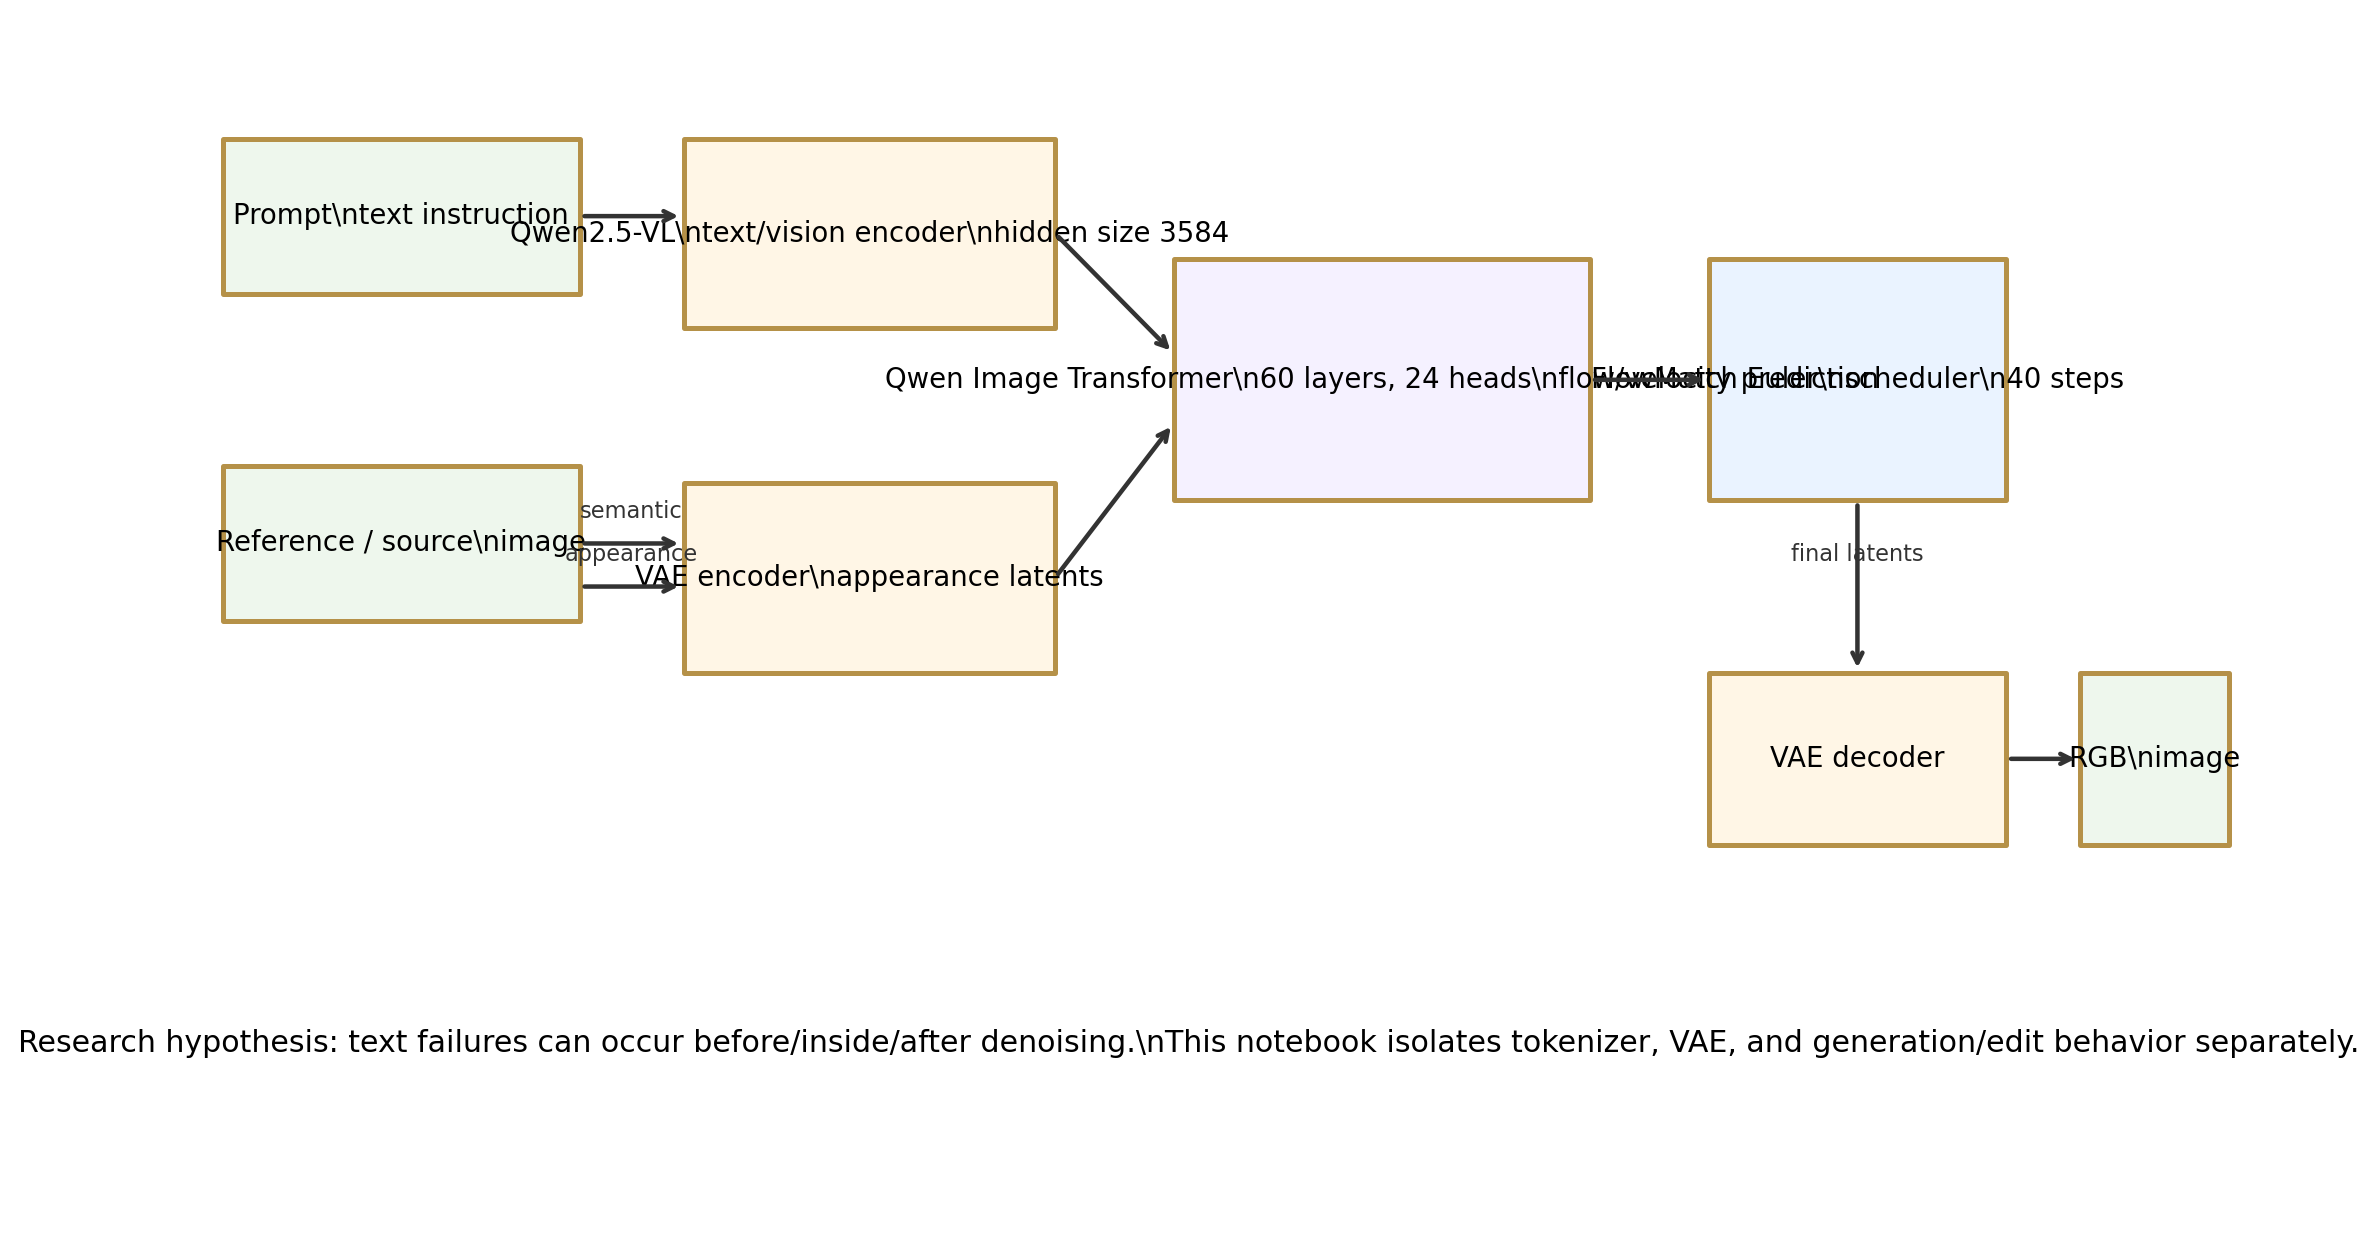

In [4]:
def draw_architecture_diagram(path: Path):
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 7)
    ax.axis("off")

    def box(x, y, w, h, label, fc="#fdf8eb", ec="#b59148", fs=11):
        rect = plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, linewidth=2, joinstyle="round")
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=fs, wrap=True)

    def arrow(x1, y1, x2, y2, label=""):
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", lw=1.8, color="#333"))
        if label:
            ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.15, label, ha="center", fontsize=9, color="#333")

    box(0.3, 5.4, 2.4, 0.9, "Prompt\\ntext instruction", "#eef7ed")
    box(0.3, 3.5, 2.4, 0.9, "Reference / source\\nimage", "#eef7ed")
    box(3.4, 5.2, 2.5, 1.1, "Qwen2.5-VL\\ntext/vision encoder\\nhidden size 3584", "#fff6e6")
    box(3.4, 3.2, 2.5, 1.1, "VAE encoder\\nappearance latents", "#fff6e6")
    box(6.7, 4.2, 2.8, 1.4, "Qwen Image Transformer\\n60 layers, 24 heads\\nflow/velocity prediction", "#f5f1ff")
    box(10.3, 4.2, 2.0, 1.4, "FlowMatch Euler\\nscheduler\\n40 steps", "#eaf3ff")
    box(10.3, 2.2, 2.0, 1.0, "VAE decoder", "#fff6e6")
    box(12.8, 2.2, 1.0, 1.0, "RGB\\nimage", "#eef7ed")

    arrow(2.7, 5.85, 3.4, 5.85)
    arrow(2.7, 3.95, 3.4, 3.95, "semantic")
    arrow(2.7, 3.7, 3.4, 3.7, "appearance")
    arrow(5.9, 5.75, 6.7, 5.05)
    arrow(5.9, 3.75, 6.7, 4.65)
    arrow(9.5, 4.9, 10.3, 4.9)
    arrow(11.3, 4.2, 11.3, 3.2, "final latents")
    arrow(12.3, 2.7, 12.8, 2.7)

    ax.text(6.8, 1.0, "Research hypothesis: text failures can occur before/inside/after denoising.\\nThis notebook isolates tokenizer, VAE, and generation/edit behavior separately.", fontsize=12, ha="center")
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)

arch_png = OUT / "qwen_edit_architecture_diagram.png"
draw_architecture_diagram(arch_png)
display(IPyImage(filename=str(arch_png)))

## 3. Tokenizer / Text Conditioning Probe

This does **not** prove whether the model can render text. It only measures how the prompt text is represented before image generation.

Things to watch:

- token count differences
- whether characters split into many pieces
- whether Arabic shaping is not represented in the prompt string; shaping must be learned by the model

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR / "tokenizer", trust_remote_code=True)

TEXT_CASES = [
    {"lang": "english", "text": "AI PIZZA", "note": "Latin uppercase"},
    {"lang": "arabic", "text": "بيتزا الذكاء الاصطناعي", "note": "Arabic RTL phrase"},
    {"lang": "chinese", "text": "人工智能披萨", "note": "Simplified Chinese phrase"},
    {"lang": "english_short", "text": "MENU", "note": "Latin short word"},
    {"lang": "arabic_short", "text": "قائمة", "note": "Arabic short word"},
    {"lang": "chinese_short", "text": "菜单", "note": "Chinese short word"},
]

token_rows = []
for item in TEXT_CASES:
    enc = tokenizer(item["text"], add_special_tokens=False)
    ids = enc.input_ids
    decoded_pieces = [tokenizer.decode([token_id]) for token_id in ids]
    token_rows.append({
        "lang": item["lang"],
        "text": item["text"],
        "chars": len(item["text"]),
        "tokens": len(ids),
        "chars_per_token": round(len(item["text"]) / max(1, len(ids)), 3),
        "token_ids": ids,
        "decoded_token_pieces": decoded_pieces,
        "note": item["note"],
    })
token_df = pd.DataFrame(token_rows)
token_df.to_csv(OUT / "tokenizer_probe.csv", index=False)
display(token_df[["lang", "text", "chars", "tokens", "chars_per_token", "note"]])
display(Markdown(
    "The token previews below are decoded per-token for readability. "
    "They are **not** final rendered glyphs and do not include Arabic shaping."
))
for row in token_rows:
    print("\\n", row["lang"], repr(row["text"]))
    print(row["decoded_token_pieces"])

,lang,text,chars,tokens,chars_per_token,note
0,english,AI PIZZA,8,4,2.000,Latin uppercase
1,arabic,بيتزا الذكاء الاصطناعي,22,11,2.000,Arabic RTL phrase
2,chinese,人工智能披萨,6,3,2.000,Simplified Chinese phrase
3,english_short,MENU,4,1,4.000,Latin short word
4,arabic_short,قائمة,5,3,1.667,Arabic short word
5,chinese_short,菜单,2,1,2.000,Chinese short word


The token previews below are decoded per-token for readability. They are **not** final rendered glyphs and do not include Arabic shaping.

\n english 'AI PIZZA'
['AI', ' P', 'IZ', 'ZA']
\n arabic 'بيتزا الذكاء الاصطناعي'
['بي', 'ت', 'زا', ' الذ', 'ك', 'اء', ' ال', 'اص', 'طن', 'اع', 'ي']
\n chinese '人工智能披萨'
['人工智能', '披', '萨']
\n english_short 'MENU'
['MENU']
\n arabic_short 'قائمة'
['ق', 'ائ', 'مة']
\n chinese_short '菜单'
['菜单']


## 4. Synthetic Text Controls

We render known-good text ourselves. These controls tell us what the glyphs should look like before Qwen touches them.

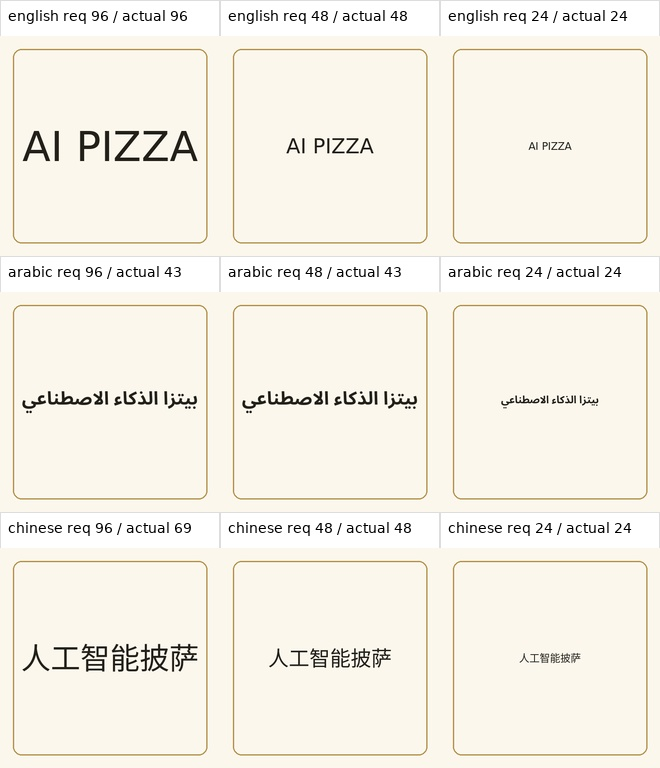

,lang,text,requested_font_size,actual_font_size,source_path
0,english,AI PIZZA,96,96,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
1,english,AI PIZZA,48,48,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
2,english,AI PIZZA,24,24,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
3,arabic,بيتزا الذكاء الاصطناعي,96,43,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
4,arabic,بيتزا الذكاء الاصطناعي,48,43,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
5,arabic,بيتزا الذكاء الاصطناعي,24,24,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
6,chinese,人工智能披萨,96,69,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
7,chinese,人工智能披萨,48,48,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
8,chinese,人工智能披萨,24,24,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...


In [6]:
def shaped_arabic(text: str) -> str:
    return get_display(arabic_reshaper.reshape(text))

def font_for(lang: str, size: int, bold: bool = False):
    if lang == "arabic":
        path = FONT_AR_BOLD if bold and FONT_AR_BOLD.exists() else FONT_AR_REG
    elif lang == "chinese":
        path = FONT_CJK
    else:
        path = FONT_LATIN
    return ImageFont.truetype(str(path), size)

def text_bbox(draw: ImageDraw.ImageDraw, render_text: str, font: ImageFont.FreeTypeFont):
    bbox = draw.textbbox((0, 0), render_text, font=font)
    return bbox, bbox[2] - bbox[0], bbox[3] - bbox[1]

def fit_font_size(text: str, lang: str, requested_size: int, draw: ImageDraw.ImageDraw, max_width: int, max_height: int) -> tuple[ImageFont.FreeTypeFont, str, int, tuple[int, int, int, int]]:
    render_text = shaped_arabic(text) if lang == "arabic" else text
    for size in range(requested_size, 11, -1):
        font = font_for(lang, size, bold=True)
        bbox, tw, th = text_bbox(draw, render_text, font)
        if tw <= max_width and th <= max_height:
            return font, render_text, size, bbox
    font = font_for(lang, 12, bold=True)
    bbox, _, _ = text_bbox(draw, render_text, font)
    return font, render_text, 12, bbox

def draw_centered_text_card(text: str, lang: str, requested_font_size: int, size=(512, 512)) -> tuple[Image.Image, int]:
    image = Image.new("RGB", size, "#fbf7ed")
    draw = ImageDraw.Draw(image)
    draw.rounded_rectangle((30, 30, size[0]-30, size[1]-30), radius=20, outline="#b59148", width=3)
    font, render_text, actual_size, bbox = fit_font_size(
        text,
        lang,
        requested_font_size,
        draw,
        max_width=size[0] - 96,
        max_height=size[1] - 180,
    )
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    draw.text(((size[0]-tw)/2, (size[1]-th)/2 - bbox[1]), render_text, fill="#222019", font=font)
    return image, actual_size

synth_rows = []
synth_images = []
for lang, text in [("english", "AI PIZZA"), ("arabic", "بيتزا الذكاء الاصطناعي"), ("chinese", "人工智能披萨")]:
    for font_size in [96, 48, 24]:
        img, actual_font_size = draw_centered_text_card(text, lang, font_size)
        path = SYNTH_DIR / f"{lang}_font{font_size}_source.png"
        img.save(path)
        synth_rows.append({
            "lang": lang,
            "text": text,
            "requested_font_size": font_size,
            "actual_font_size": actual_font_size,
            "source_path": str(path),
        })
        synth_images.append((f"{lang} req {font_size} / actual {actual_font_size}", path))

synth_df = pd.DataFrame(synth_rows)
synth_df.to_csv(OUT / "synthetic_controls.csv", index=False)

def make_sheet(items, out_path: Path, thumb=(220, 220), cols=3):
    rows = math.ceil(len(items) / cols)
    label_h = 36
    sheet = Image.new("RGB", (cols * thumb[0], rows * (thumb[1] + label_h)), "white")
    d = ImageDraw.Draw(sheet)
    label_font = ImageFont.truetype(str(FONT_LATIN), 14)
    for i, (label, path) in enumerate(items):
        im = ImageOps.exif_transpose(Image.open(path)).convert("RGB")
        im.thumbnail(thumb, Image.Resampling.LANCZOS)
        x = (i % cols) * thumb[0]
        y = (i // cols) * (thumb[1] + label_h)
        d.rectangle((x, y, x + thumb[0] - 1, y + thumb[1] + label_h - 1), outline="#ddd")
        d.text((x + 8, y + 8), label, fill="black", font=label_font)
        sheet.paste(im, (x + (thumb[0]-im.width)//2, y + label_h + (thumb[1]-im.height)//2))
    sheet.save(out_path, quality=95)
    return out_path

synth_sheet = make_sheet(synth_images, OUT / "synthetic_text_controls_contact_sheet.jpg")
display(IPyImage(filename=str(synth_sheet)))
display(synth_df)

## 5. VAE Reconstruction Probe

This isolates one possible bottleneck: can the VAE preserve text-like glyph detail if the text is already present?

Method:

- render synthetic text cards ourselves
- encode with Qwen VAE
- decode with Qwen VAE
- compare source vs reconstruction visually and with simple SSIM/MSE

If the VAE destroys small glyphs, then even a perfect denoiser would have trouble preserving/editing tiny text. If the VAE preserves them but generation fails, the bottleneck is more likely conditioning/denoising/training prior.

Loading VAE on cuda


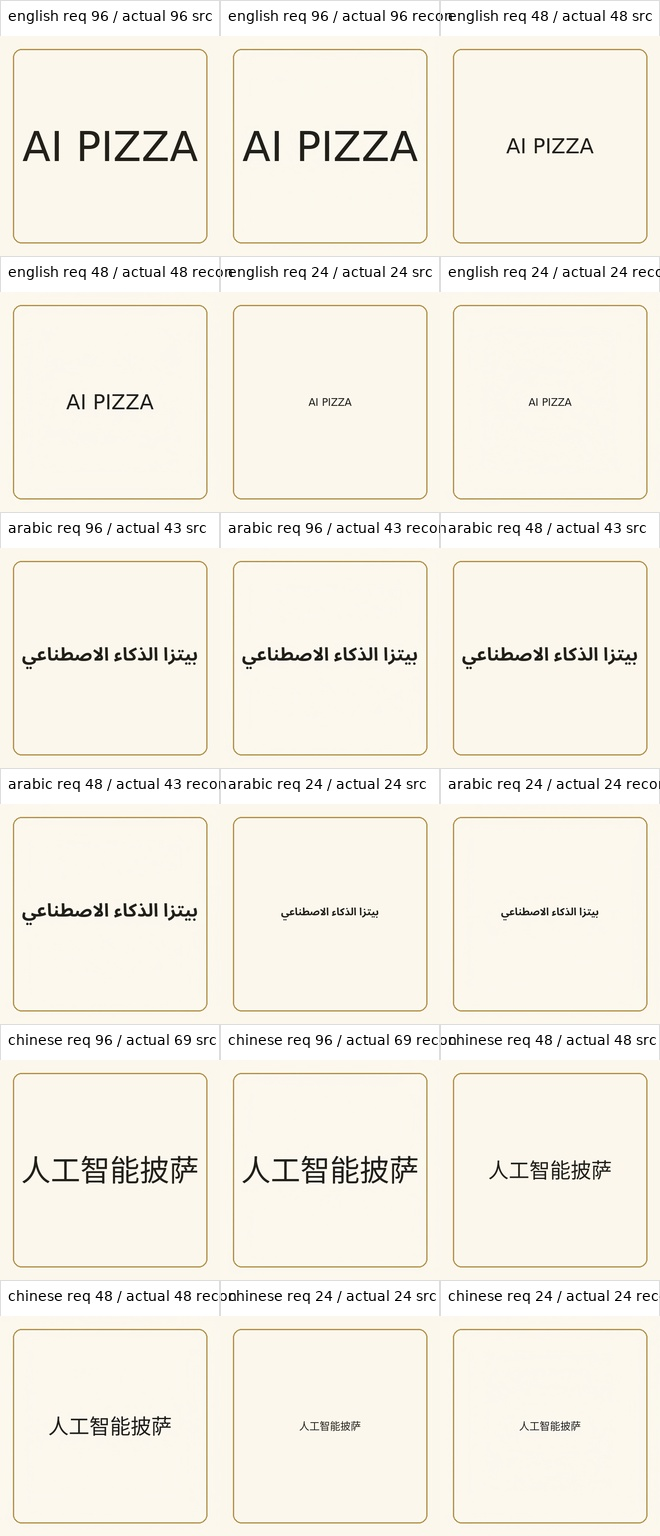

,lang,requested_font_size,actual_font_size,mse,ssim,source_path,recon_path
0,english,96,96,0.000031,0.998263,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
1,english,48,48,0.000029,0.998186,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
2,english,24,24,0.000027,0.997705,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
3,arabic,96,43,0.000037,0.998395,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
4,arabic,48,43,0.000037,0.998395,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
5,arabic,24,24,0.000038,0.998635,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
6,chinese,96,69,0.000048,0.998407,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
7,chinese,48,48,0.000049,0.998416,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...
8,chinese,24,24,0.000045,0.997857,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...


In [7]:
def pil_to_vae_tensor(image: Image.Image, device: str, dtype: torch.dtype):
    arr = np.array(image.convert("RGB")).astype("float32") / 255.0
    tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).unsqueeze(2)
    tensor = tensor * 2.0 - 1.0
    return tensor.to(device=device, dtype=dtype)

def vae_tensor_to_pil(tensor: torch.Tensor) -> Image.Image:
    # tensor shape: [B, C, F, H, W]
    x = tensor.detach().float().cpu().clamp(-1, 1)
    x = ((x[0, :, 0] + 1) / 2).clamp(0, 1)
    arr = (x.permute(1, 2, 0).numpy() * 255).round().astype("uint8")
    return Image.fromarray(arr)

print("Loading VAE on", VAE_DEVICE)
vae = AutoencoderKLQwenImage.from_pretrained(MODEL_DIR / "vae", torch_dtype=torch.bfloat16).to(VAE_DEVICE)
vae.eval()

vae_rows = []
vae_pairs = []
with torch.inference_mode():
    for row in synth_rows:
        src = Image.open(row["source_path"]).convert("RGB")
        x = pil_to_vae_tensor(src, VAE_DEVICE, torch.bfloat16)
        encoded = vae.encode(x)
        # Use deterministic mode rather than sampling so the probe is reproducible.
        latents = encoded.latent_dist.mode()
        decoded = vae.decode(latents).sample
        recon = vae_tensor_to_pil(decoded)
        out_path = VAE_DIR / f"{row['lang']}_font{row['requested_font_size']}_recon.png"
        recon.save(out_path)
        src_arr = np.array(src.convert("L")).astype("float32") / 255
        rec_arr = np.array(recon.convert("L")).astype("float32") / 255
        mse = float(np.mean((src_arr - rec_arr) ** 2))
        score = float(ssim(src_arr, rec_arr, data_range=1.0))
        vae_rows.append({**row, "recon_path": str(out_path), "mse": mse, "ssim": score})
        label = f"{row['lang']} req {row['requested_font_size']} / actual {row['actual_font_size']}"
        vae_pairs.append((f"{label} src", row["source_path"]))
        vae_pairs.append((f"{label} recon", out_path))

del vae
if torch.cuda.is_available():
    torch.cuda.empty_cache()

vae_df = pd.DataFrame(vae_rows)
vae_df.to_csv(OUT / "vae_reconstruction_metrics.csv", index=False)
vae_sheet = make_sheet(vae_pairs, OUT / "vae_reconstruction_contact_sheet.jpg", cols=3)
display(IPyImage(filename=str(vae_sheet)))
display(vae_df[["lang", "requested_font_size", "actual_font_size", "mse", "ssim", "source_path", "recon_path"]])

## 6. Initial Fixed-Seed Qwen Rendering Matrix

This starts the actual Qwen output study. It is intentionally minimal:

- same seed
- same canvas size
- same steps and true CFG
- no Groq/prompt enhancer
- simple background
- exact target text

Initial scenarios:

- **text-to-image large sign**
- **edit blank card large sign**

Later extensions should add small text, multiple seeds, background complexity, and reference-glyph copying.

t2i_large_sign_english ok wall=10.44s 


edit_blank_large_sign_english ok wall=29.35s 


t2i_large_sign_arabic ok wall=10.50s 


edit_blank_large_sign_arabic ok wall=29.50s 


t2i_large_sign_chinese ok wall=10.51s 


edit_blank_large_sign_chinese ok wall=29.64s 


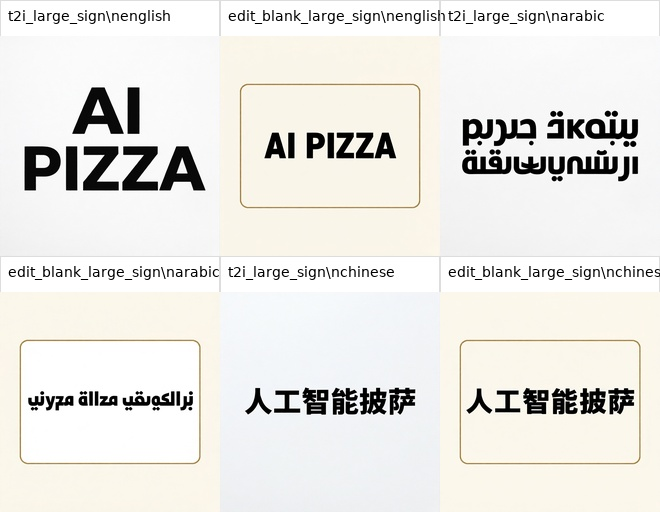

,scenario,lang,target_text,status,elapsed_seconds,wall_seconds,output_path,human_label
0,t2i_large_sign,english,AI PIZZA,ok,10.430476,10.438767,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,unreviewed
1,edit_blank_large_sign,english,AI PIZZA,ok,29.341170,29.354308,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,unreviewed
2,t2i_large_sign,arabic,بيتزا الذكاء الاصطناعي,ok,10.492073,10.499575,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,unreviewed
3,edit_blank_large_sign,arabic,بيتزا الذكاء الاصطناعي,ok,29.492484,29.504590,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,unreviewed
4,t2i_large_sign,chinese,人工智能披萨,ok,10.497438,10.505760,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,unreviewed
5,edit_blank_large_sign,chinese,人工智能披萨,ok,29.631248,29.644389,/mnt/local-fast/aalhejab/Qwen-Image-Edit-2511-...,unreviewed


In [8]:
def b64_image(path: Path) -> str:
    return base64.b64encode(path.read_bytes()).decode("ascii")

def decode_response_image(data: str, path: Path) -> None:
    if "," in data:
        data = data.split(",", 1)[1]
    path.write_bytes(base64.b64decode(data))

def call_qwen(payload: dict[str, Any], timeout: int = 900) -> dict[str, Any]:
    request = urllib.request.Request(
        API,
        data=json.dumps(payload).encode("utf-8"),
        headers={"Content-Type": "application/json"},
    )
    with urllib.request.urlopen(request, timeout=timeout) as response:
        return json.load(response)

blank = Image.new("RGB", (WIDTH, HEIGHT), "#fbf7ed")
d = ImageDraw.Draw(blank)
d.rounded_rectangle((70, 170, WIDTH - 70, HEIGHT - 170), radius=28, fill="white", outline="#b59148", width=4)
blank_path = API_DIR / "blank_card_reference.png"
blank.save(blank_path)

matrix_cases = [
    {"lang": "english", "text": "AI PIZZA"},
    {"lang": "arabic", "text": "بيتزا الذكاء الاصطناعي"},
    {"lang": "chinese", "text": "人工智能披萨"},
]
scenario_templates = {
    "t2i_large_sign": {
        "images": [],
        "prompt": 'Create a plain white square poster with only the exact text "{text}" centered in very large black clean sans-serif letters. No other text, no logo, no watermark, no decoration.',
        "role": [],
    },
    "edit_blank_large_sign": {
        "images": [b64_image(blank_path)],
        "prompt": 'Edit the provided blank card by writing exactly "{text}" centered in very large black clean sans-serif letters. Preserve the blank cream card and border. No other text, no logo, no watermark.',
        "role": ["Blank cream card reference to edit; add only the requested centered text."],
    },
}

api_rows = []
api_items = []
for case in matrix_cases:
    for scenario, spec in scenario_templates.items():
        name = f"{scenario}_{case['lang']}"
        prompt = spec["prompt"].format(text=case["text"])
        payload = {
            "prompt": prompt,
            "images": spec["images"],
            "image_roles": spec["role"],
            "enhance_prompt": False,
            "negative_prompt": "extra text, misspelled text, pseudo text, watermark, logo, decorative letters",
            "seed": FIXED_SEED,
            "height": HEIGHT,
            "width": WIDTH,
            "num_inference_steps": STEPS,
            "true_cfg_scale": TRUE_CFG_SCALE,
            "max_sequence_length": 512,
            "output_format": "jpeg",
            "jpeg_quality": 95,
        }
        started = time.perf_counter()
        try:
            response = call_qwen(payload)
            wall = time.perf_counter() - started
            out_path = API_DIR / f"{name}.jpg"
            decode_response_image(response["image"], out_path)
            meta = {k: v for k, v in response.items() if k != "image"}
            (API_DIR / f"{name}.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
            status = "ok"
            error = ""
            elapsed = response.get("elapsed_seconds")
        except Exception as exc:
            wall = time.perf_counter() - started
            out_path = ""
            status = "failed"
            error = repr(exc)
            elapsed = None
        api_rows.append({
            "scenario": scenario,
            "lang": case["lang"],
            "target_text": case["text"],
            "seed": FIXED_SEED,
            "steps": STEPS,
            "true_cfg_scale": TRUE_CFG_SCALE,
            "width": WIDTH,
            "height": HEIGHT,
            "status": status,
            "elapsed_seconds": elapsed,
            "wall_seconds": wall,
            "output_path": str(out_path),
            "human_label": "unreviewed",
            "error": error,
            "prompt": prompt,
        })
        if status == "ok":
            api_items.append((f"{scenario}\\n{case['lang']}", Path(out_path)))
        print(name, status, f"wall={wall:.2f}s", error)

api_df = pd.DataFrame(api_rows)
api_df.to_csv(OUT / "initial_qwen_api_matrix.csv", index=False)
api_sheet = make_sheet(api_items, OUT / "initial_qwen_api_matrix_contact_sheet.jpg", cols=3)
display(IPyImage(filename=str(api_sheet)))
display(api_df[["scenario", "lang", "target_text", "status", "elapsed_seconds", "wall_seconds", "output_path", "human_label"]])

## 7. Manual Review Protocol

Use the contact sheets above and fill `human_label` in `initial_qwen_api_matrix.csv`.

Suggested labels:

- `exact`
- `mostly_correct`
- `wrong_script`
- `malformed_glyphs`
- `pseudo_text`
- `missing_text`
- `extra_text`
- `layout_ok_text_bad`

Do not rely only on a VLM/OCR model for final judgment. OCR/VLM review can be a helper, but visual inspection is the ground truth for this research.

## 8. Working Hypotheses To Test Next

**Measured in this notebook already**

- Tokenization differs by script.
- VAE preservation can be measured independently from generation.
- Qwen text-to-image and Qwen edit can be compared under the same seed/prompt/resolution.

**Likely, but not proven by the first pass**

- Small text failures are often a latent-resolution and denoising precision problem.
- Arabic can fail from training distribution and shaping/ligature priors, not just tokenizer count.
- Chinese may be better than Arabic in Qwen because the model/card emphasizes Chinese-English text editing support and likely has stronger Chinese text-rendering training.

**Unknown without deeper work**

- Which exact transformer layers/heads store glyph layout.
- Whether failures are mostly due to data imbalance, objective weighting, VAE compression, or decoder prior.
- Whether finetuning should target the transformer only, VAE, text encoder, or a separate post-generation repair model.

Next notebook extension:

- add small/medium/large text generation matrix
- add multiple seeds
- add reference-glyph copy scenarios
- add background complexity
- add Qwen-VL review as a secondary judge
- compare with external models only after Qwen-only baselines are clear

## 9. Preliminary Visual Read From The Starter Run

This is a first human visual pass over `initial_qwen_api_matrix_contact_sheet.jpg`.

Observed under the same seed, resolution, scheduler, steps, and true CFG:

- English large text succeeds in both text-to-image and blank-card edit.
- Chinese large text succeeds or is near-exact in both text-to-image and blank-card edit.
- Arabic large text fails in both modes: glyphs are Arabic-like but the target phrase is not preserved.

The synthetic control images now auto-fit text before VAE encoding, so the VAE probe is not based on clipped Arabic or Chinese source images. The VAE still preserves already-rendered Arabic and Chinese well at these fitted sizes. That points away from “VAE alone destroyed Arabic” for this first case. The failure is more likely in prompt conditioning, denoising, training prior, or their interaction. This is still a hypothesis, not proof.

Saved reviewed table: `outputs/qwen_text_failure_study/initial_qwen_api_matrix_reviewed.csv`.